# Optimisation de portefeuille CAC40 — Pipeline complet

Ce notebook couvre :
1. Téléchargement des données CAC40 via yfinance
2. Calcul des rendements et statistiques
3. Optimisation SGD (mean-variance avec actif sans risque)
4. Backtest et métriques de performance
5. Comparaison des stratégies
6. Visualisations

## 0. Imports

In [265]:
import sys
import os
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import matplotlib.dates as mdates

sys.path.append(os.path.abspath('..'))


from ext.portfolio_math import (
    estimate_expected_returns,
    estimate_covariance_matrix,
    add_risk_free_asset,
    split_weights,
    mean_variance_cost,
    mean_variance_gradient,
    enforce_portfolio_constraints,
)
from ext.sgd_optimizer import initialize_weights, run_sgd
from ext.portfolio_backtest import (
    run_static_backtest,
    run_portfolio_backtest,
)
from ext.ml_signals import build_ml_signals

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Imports OK')

Imports OK


## 1. Données CAC40

In [266]:
# Sous-ensemble représentatif du CAC40 — 12 actions couvrant plusieurs secteurs
# Luxe / Conso : MC.PA, RMS.PA, OR.PA
# Industrie    : AIR.PA, SAN.PA, DG.PA
# Banque / Assu: BNP.PA, ACA.PA, CS.PA
# Energie / Util: TTE.PA, EDF.PA, EN.PA

TICKERS = [
    'MC.PA',   # LVMH
    'RMS.PA',  # Hermès
    'OR.PA',   # L'Oréal
    'AIR.PA',  # Airbus
    'SAN.PA',  # Sanofi
    'DG.PA',   # Vinci
    'BNP.PA',  # BNP Paribas
    'ACA.PA',  # Crédit Agricole
	'CS.PA',   # Crédit Suisse
    'TTE.PA',  # TotalEnergies
    'EN.PA',   # Bouygues
    'VIE.PA',  # Veolia
    'CAP.PA',  # Capgemini
]

START_DATE      = '2010-01-01'
END_DATE        = '2026-02-05'
RISK_FREE_RATE  = 0.03   # taux OAT 10 ans approx annuel
ANNUALIZATION   = 252

print(f'{len(TICKERS)} actifs | {START_DATE} → {END_DATE}')
print(f'Taux sans risque : {RISK_FREE_RATE:.1%} annuel')

13 actifs | 2010-01-01 → 2026-02-05
Taux sans risque : 3.0% annuel


In [267]:
# Téléchargement des prix de clôture ajustés
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
price_data = raw['Close'].dropna(how='all')

# Supprimer les actifs avec trop de données manquantes (> 5%)
missing_pct = price_data.isnull().mean()
tickers_ok  = missing_pct[missing_pct < 0.05].index.tolist()
price_data  = price_data[tickers_ok].ffill().dropna()

print(f'Actifs retenus   : {len(tickers_ok)}')
print(f'Période effective: {price_data.index[0].date()} → {price_data.index[-1].date()}')
print(f'Nombre de jours  : {len(price_data)}')
price_data.tail(3)

Actifs retenus   : 13
Période effective: 2010-01-04 → 2026-02-04
Nombre de jours  : 4118


Ticker,ACA.PA,AIR.PA,BNP.PA,CAP.PA,CS.PA,DG.PA,EN.PA,MC.PA,OR.PA,RMS.PA,SAN.PA,TTE.PA,VIE.PA
Date,,,,,,,,,,,,,
2026-02-02,18.480000,190.283966,92.379997,134.300003,38.930000,118.234558,44.713818,529.663208,381.210999,2011.728638,80.449997,59.993916,31.530001
2026-02-03,18.745001,186.788544,91.919998,121.949997,39.310001,119.011459,44.915272,520.512451,379.004364,1982.027832,81.080002,60.834999,31.959999
2026-02-04,18.174999,184.844467,90.930000,119.099998,40.130001,120.662369,44.905682,527.498535,391.704834,2014.698730,81.839996,61.903667,32.099998


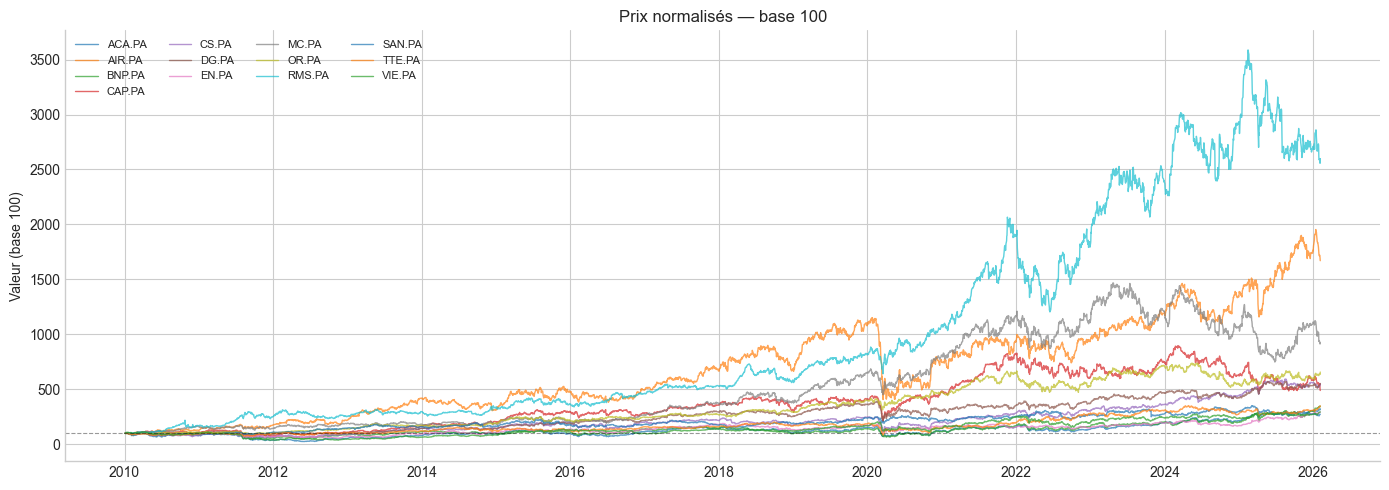

In [268]:
# Visualisation des prix normalisés (base 100)
fig, ax = plt.subplots(figsize=(14, 5))
normalized = price_data / price_data.iloc[0] * 100
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], linewidth=1, alpha=0.7, label=col)
ax.axhline(100, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_title('Prix normalisés — base 100')
ax.set_ylabel('Valeur (base 100)')
ax.legend(ncol=4, fontsize=8, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 2. Rendements et statistiques

In [269]:
# Rendements journaliers simples
returns_matrix = price_data.pct_change().dropna()

# Séparation train / test (80% / 20%)
split_idx    = int(len(returns_matrix) * 0.8)
returns_train = returns_matrix.iloc[:split_idx]
returns_test  = returns_matrix.iloc[split_idx:]
price_test    = price_data.iloc[split_idx:]

print(f'Train : {returns_train.index[0].date()} → {returns_train.index[-1].date()} ({len(returns_train)} jours)')
print(f'Test  : {returns_test.index[0].date()}  → {returns_test.index[-1].date()} ({len(returns_test)} jours)')

Train : 2010-01-05 → 2022-11-11 (3293 jours)
Test  : 2022-11-14  → 2026-02-04 (824 jours)


In [270]:
# Statistiques descriptives annualisées (sur train)
mu    = estimate_expected_returns(returns_train)
Sigma = estimate_covariance_matrix(returns_train)

stats = pd.DataFrame({
    'Rendement annualisé (%)' : mu * ANNUALIZATION * 100,
    'Volatilité annualisée (%)': np.sqrt(np.diag(Sigma) * ANNUALIZATION) * 100,
    'Sharpe individuel'        : (mu * ANNUALIZATION - RISK_FREE_RATE) /
                                  (np.sqrt(np.diag(Sigma) * ANNUALIZATION)),
}, index=tickers_ok)

stats.sort_values('Sharpe individuel', ascending=False).round(3)

,Rendement annualisé (%),Volatilité annualisée (%),Sharpe individuel
RMS.PA,25.373,25.129,0.890
MC.PA,22.344,27.241,0.710
AIR.PA,23.411,35.135,0.581
OR.PA,15.325,21.739,0.567
CAP.PA,19.392,29.876,0.549
DG.PA,13.780,27.196,0.396
CS.PA,13.577,31.669,0.334
TTE.PA,10.854,26.195,0.300
SAN.PA,9.238,21.919,0.285
VIE.PA,9.399,29.772,0.215


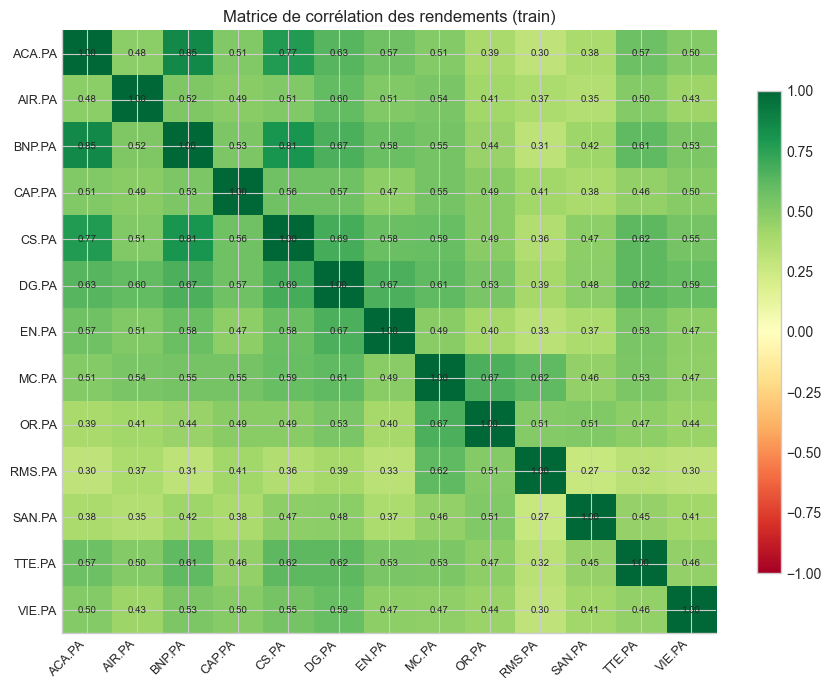

In [271]:
# Matrice de corrélation
corr = returns_train.corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(tickers_ok)))
ax.set_yticks(range(len(tickers_ok)))
ax.set_xticklabels(tickers_ok, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(tickers_ok, fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)
for i in range(len(tickers_ok)):
    for j in range(len(tickers_ok)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_title('Matrice de corrélation des rendements (train)')
plt.tight_layout()
plt.show()

## 3. Optimisation SGD

In [272]:
# Extension avec actif sans risque
rf_daily = RISK_FREE_RATE / ANNUALIZATION
mu_ext, Sigma_ext = add_risk_free_asset(mu, Sigma, rf_daily)

n_assets = len(mu_ext) # N actifs risqués + 1 sans risque
print(f'Dimension du vecteur de poids : {n_assets} ({n_assets-1} actifs + 1 sans risque)')

Dimension du vecteur de poids : 14 (13 actifs + 1 sans risque)


In [273]:
SGD_PARAMS = dict(
    n_iterations=600000,
    learning_rate=0.0001,
    batch_size=4096,
    lambda_risk=1.0,
    annualization_factor=ANNUALIZATION,
    verbose=True,
)

returns_train_risky = returns_train[TICKERS]
returns_train_with_rf = returns_train[TICKERS].copy()
returns_train_with_rf["RF"] = RISK_FREE_RATE / ANNUALIZATION

n_assets = returns_train_with_rf.shape[1]

w0 = initialize_weights(n_assets, method="equal")

results_sgd = run_sgd(
    returns_matrix=returns_train_with_rf,
    initial_weights=w0,
    constraint_function=enforce_portfolio_constraints,
    **SGD_PARAMS
)

wr, wrf = split_weights(results_sgd["final_weights"])

Itération     0  J = -0.097188  ||g|| = 3.2268e-01
Itération    50  J = -0.097484  ||g|| = 3.2260e-01
Itération   100  J = -0.097778  ||g|| = 3.2252e-01
Itération   150  J = -0.098071  ||g|| = 3.2245e-01
Itération   200  J = -0.098362  ||g|| = 3.2237e-01
Itération   250  J = -0.098651  ||g|| = 3.2230e-01
Itération   300  J = -0.098938  ||g|| = 3.2222e-01
Itération   350  J = -0.099224  ||g|| = 3.2215e-01
Itération   400  J = -0.099508  ||g|| = 3.2208e-01
Itération   450  J = -0.099790  ||g|| = 3.2200e-01
Itération   500  J = -0.100071  ||g|| = 3.2193e-01
Itération   550  J = -0.100350  ||g|| = 3.2186e-01
Itération   600  J = -0.100627  ||g|| = 3.2179e-01
Itération   650  J = -0.100903  ||g|| = 3.2172e-01
Itération   700  J = -0.101177  ||g|| = 3.2164e-01
Itération   750  J = -0.101449  ||g|| = 3.2157e-01
Itération   800  J = -0.101720  ||g|| = 3.2150e-01
Itération   850  J = -0.101990  ||g|| = 3.2144e-01
Itération   900  J = -0.102257  ||g|| = 3.2137e-01
Itération   950  J = -0.102524 

In [274]:
print(f"Convergé        : {results_sgd['converged']}")
print(f"Itérations      : {results_sgd['n_iterations']}")
print(f"Coût final      : {results_sgd['cost_history'][-1]:.6f}")

w_all = results_sgd["final_weights"]

poids_df = pd.DataFrame({
    "Actif": returns_train_with_rf.columns,
    "Poids (%)": w_all * 100
}).sort_values("Poids (%)", ascending=False)

print(poids_df.to_string(index=False))

w_rf = poids_df.loc[poids_df["Actif"] == "RF", "Poids (%)"].iloc[0]

print(f"\nPart sans risque : {w_rf:.2f}%")

Convergé        : True
Itérations      : 34851
Coût final      : -0.147317
 Actif  Poids (%)
RMS.PA  20.398245
 MC.PA  14.763543
AIR.PA  14.435204
CAP.PA  11.926993
 OR.PA  10.227626
 DG.PA   6.174083
SAN.PA   5.072747
 CS.PA   5.014091
TTE.PA   4.547688
    RF   3.640553
VIE.PA   2.650153
 EN.PA   0.865435
BNP.PA   0.283640
ACA.PA   0.000000

Part sans risque : 3.64%


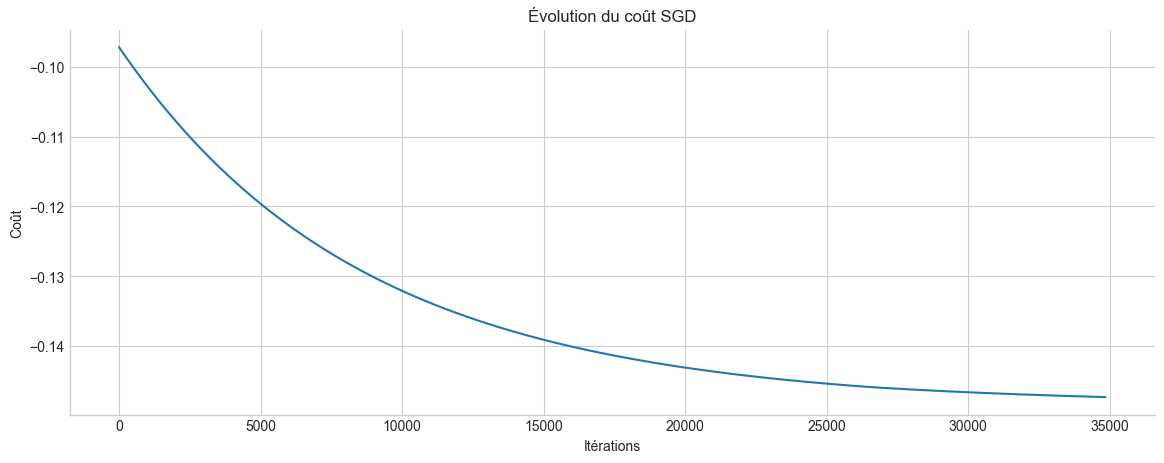

In [275]:
plt.plot(results_sgd["cost_history"])
plt.title("Évolution du coût SGD")
plt.xlabel("Itérations")
plt.ylabel("Coût")
plt.show()

In [276]:
w_all = results_sgd["final_weights"]

returns_test_with_rf = returns_test[TICKERS].copy()
returns_test_with_rf["RF"] = RISK_FREE_RATE / ANNUALIZATION

train_results = run_portfolio_backtest(
    returns_train_with_rf,
    optimized_weights=w_all
)

test_results = run_portfolio_backtest(
    returns_test_with_rf,
    optimized_weights=w_all
)

print(train_results["comparison"])
print(test_results["comparison"])

              cumulative_return  annualized_return  volatility  \
equal_weight           3.625500           0.124351    0.201596   
optimized              7.858749           0.181676    0.198780   

              theoretical_volatility  sharpe_ratio  max_drawdown  
equal_weight                0.201596      0.683661     -0.401415  
optimized                   0.198780      0.939885     -0.394690  
              cumulative_return  annualized_return  volatility  \
equal_weight           0.470090           0.125066    0.132299   
optimized              0.285257           0.079772    0.159930   

              theoretical_volatility  sharpe_ratio  max_drawdown  
equal_weight                0.132299      0.962768     -0.141658  
optimized                   0.159930      0.554075     -0.184681  


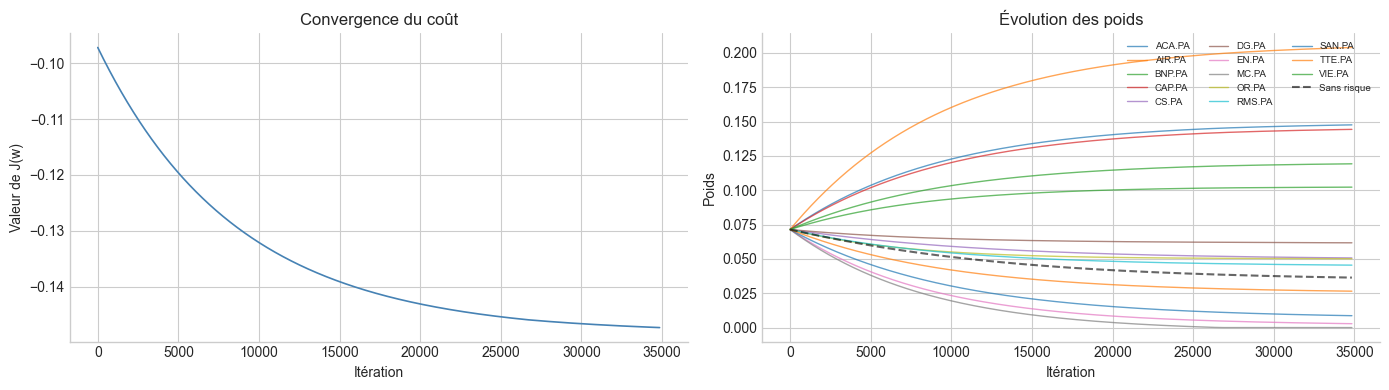

In [277]:
# Courbe de convergence du PGD
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Coût
axes[0].plot(results_sgd['cost_history'], color='steelblue', linewidth=1.2)
axes[0].set_title('Convergence du coût')
axes[0].set_xlabel('Itération')
axes[0].set_ylabel('Valeur de J(w)')

# Évolution des poids dans le temps
weights_hist = np.array(results_sgd['weights_history'])
for i, ticker in enumerate(tickers_ok):
    axes[1].plot(weights_hist[:, i], linewidth=1, alpha=0.7, label=ticker)
axes[1].plot(weights_hist[:, -1], linewidth=1.5, linestyle='--',
             color='black', alpha=0.6, label='Sans risque')
axes[1].set_title('Évolution des poids')
axes[1].set_xlabel('Itération')
axes[1].set_ylabel('Poids')
axes[1].legend(ncol=3, fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

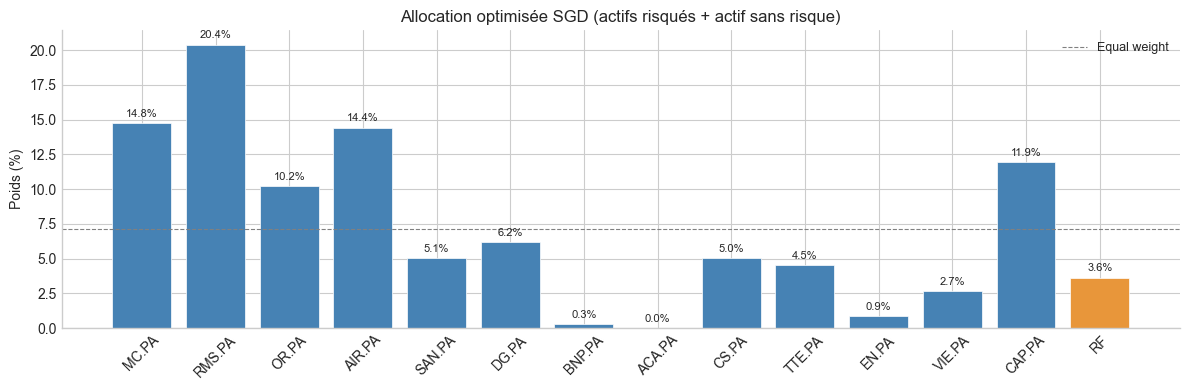

In [278]:
# Allocation finale — graphique en barres

w_all = results_sgd["final_weights"]
labels = list(returns_train_with_rf.columns)

colors = ['steelblue'] * len(labels)
colors[-1] = '#E8963A'   # dernière colonne = RF

fig, ax = plt.subplots(figsize=(12, 4))

bars = ax.bar(
    labels,
    w_all * 100,
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

ax.axhline(
    100 / len(labels),
    color='gray',
    linestyle='--',
    linewidth=0.8,
    label='Equal weight'
)

for bar, val in zip(bars, w_all):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1%}',
        ha='center',
        va='bottom',
        fontsize=8
    )

ax.set_title('Allocation optimisée SGD (actifs risqués + actif sans risque)')
ax.set_ylabel('Poids (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Signaux ML dynamiques

In [279]:
# Construction des signaux sur les données d'entraînement
ml_results = build_ml_signals(
    price_data   = price_data,
    window       = 20,
    method       = 'momentum_volatility',
    long_only    = True,
    fallback     = 'equal',
    align_for_backtest = True,
)

dynamic_weights = ml_results['weights_for_backtest']
# Restreindre à la période de test
dynamic_weights_test = dynamic_weights.loc[
    dynamic_weights.index.intersection(returns_test.index)
]

print(f'Poids dynamiques : {dynamic_weights_test.shape[0]} dates × {dynamic_weights_test.shape[1]} actifs')
dynamic_weights_test.describe().round(4)

Poids dynamiques : 824 dates × 13 actifs


Ticker,ACA.PA,AIR.PA,BNP.PA,CAP.PA,CS.PA,DG.PA,EN.PA,MC.PA,OR.PA,RMS.PA,SAN.PA,TTE.PA,VIE.PA
count,824.0000,824.0000,824.0000,824.0000,824.0000,824.0000,824.0000,824.0000,824.0000,824.0000,824.0000,824.0000,824.0000
mean,0.1088,0.1107,0.0916,0.0552,0.0714,0.0572,0.0770,0.0564,0.0592,0.0711,0.0901,0.0924,0.0589
std,0.1146,0.1572,0.0977,0.0846,0.0784,0.0645,0.0962,0.0793,0.0886,0.0959,0.1552,0.1638,0.0847
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0911,0.0708,0.0804,0.0156,0.0614,0.0371,0.0590,0.0173,0.0196,0.0350,0.0322,0.0171,0.0283
75%,0.1660,0.1445,0.1373,0.0889,0.1159,0.1085,0.1249,0.0813,0.0817,0.1077,0.1095,0.1034,0.0923
max,0.7532,1.0000,0.8758,1.0000,0.5254,0.4082,1.0000,0.4293,0.5834,0.5548,1.0000,1.0000,1.0000


## 5. Backtest — période de test

In [280]:
dynamic_weights_test_with_rf = dynamic_weights_test.copy()

# Ajouter colonne RF = ce qui reste pour faire somme = 1
dynamic_weights_test_with_rf["RF"] = 1 - dynamic_weights_test_with_rf.sum(axis=1)

w_all = results_sgd["final_weights"]

backtest_results = run_portfolio_backtest(
    returns_matrix=returns_test_with_rf,
    optimized_weights=w_all,
    dynamic_weights=dynamic_weights_test_with_rf,
    initial_value=1.0,
    risk_free_rate=RISK_FREE_RATE,
    annualization_factor=ANNUALIZATION,
)

print("Tableau comparatif des stratégies :")
print()
print(backtest_results["comparison"].round(4).to_string())

Tableau comparatif des stratégies :

              cumulative_return  annualized_return  volatility  theoretical_volatility  sharpe_ratio  max_drawdown
equal_weight             0.4701             0.1251      0.1323                  0.1323        0.7360       -0.1417
optimized                0.2853             0.0798      0.1599                  0.1599        0.3665       -0.1847
dynamic                  0.4691             0.1248      0.1708                     NaN        0.6017       -0.1747


## 6. Visualisations des performances

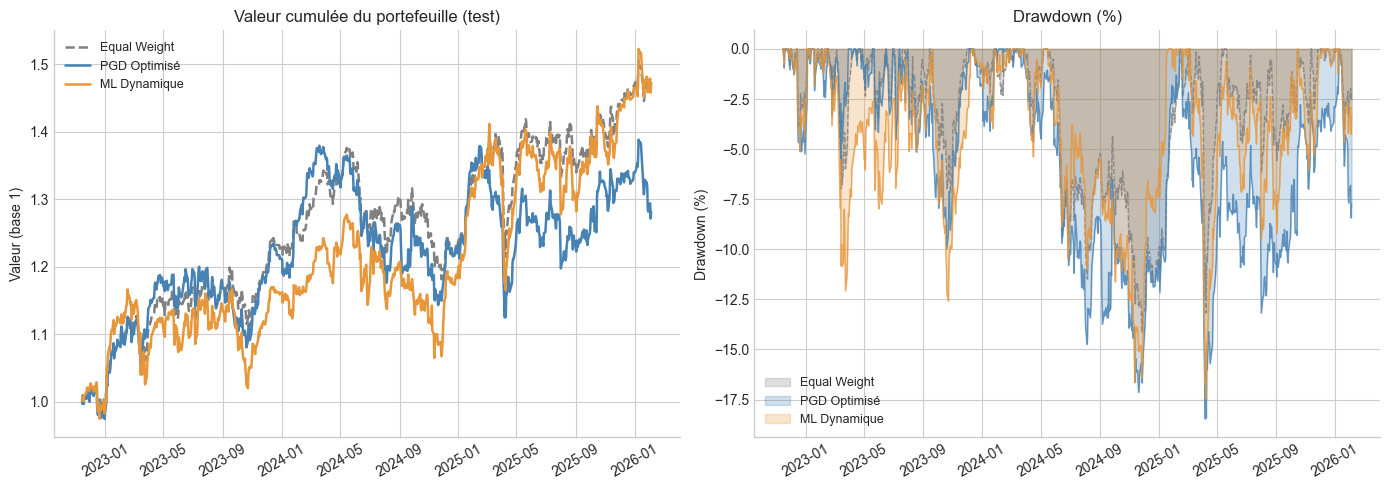

In [281]:
# Valeurs cumulées des trois stratégies
strategy_results = backtest_results['strategy_results']

LABELS = {
    'equal_weight': ('Equal Weight',  'gray',      '--'),
    'optimized'   : ('PGD Optimisé',  'steelblue', '-'),
    'dynamic'     : ('ML Dynamique',  '#E8963A',   '-'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Valeur du portefeuille
for key, (label, color, ls) in LABELS.items():
    if key in strategy_results:
        pv = strategy_results[key]['portfolio_value']
        axes[0].plot(pv.index, pv.values, label=label,
                     color=color, linestyle=ls, linewidth=1.8)
axes[0].set_title('Valeur cumulée du portefeuille (test)')
axes[0].set_ylabel('Valeur (base 1)')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# Drawdown
for key, (label, color, ls) in LABELS.items():
    if key in strategy_results:
        pv    = strategy_results[key]['portfolio_value']
        roll_max = pv.cummax()
        dd    = (pv - roll_max) / roll_max * 100
        axes[1].fill_between(dd.index, dd.values, 0,
                              alpha=0.25, color=color, label=label)
        axes[1].plot(dd.index, dd.values, color=color, linestyle=ls,
                     linewidth=1, alpha=0.8)
axes[1].set_title('Drawdown (%)')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

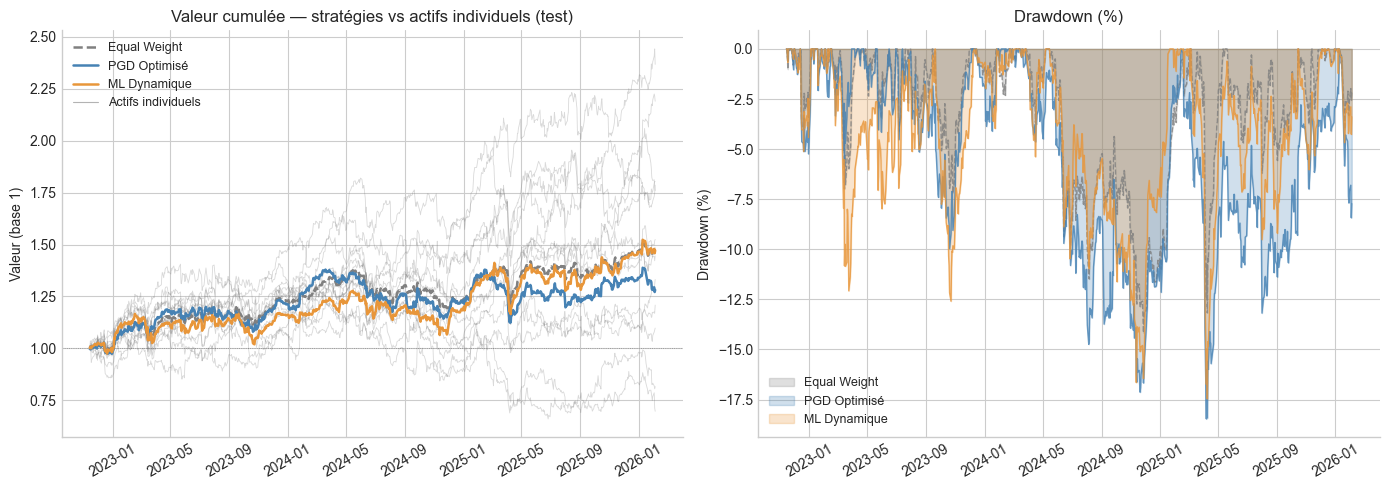

In [282]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Valeur cumulée des stratégies + prix réels normalisés ---
for key, (label, color, ls) in LABELS.items():
    if key in strategy_results:
        pv = strategy_results[key]['portfolio_value']
        axes[0].plot(pv.index, pv.values, label=label,
                     color=color, linestyle=ls, linewidth=1.8, zorder=3)

# Prix réels normalisés (base 1) sur la période de test
price_test_norm = price_data.loc[returns_test.index] 
price_test_norm = price_test_norm / price_test_norm.iloc[0]  # base 1 comme les stratégies

for col in price_test_norm.columns:
    axes[0].plot(price_test_norm.index, price_test_norm[col],
                 linewidth=0.6, alpha=0.25, color='dimgray', zorder=1)

# Une seule entrée de légende pour tous les actifs individuels
axes[0].plot([], [], linewidth=0.8, alpha=0.5, color='dimgray', label='Actifs individuels')

axes[0].axhline(1, color='black', linewidth=0.6, linestyle=':', alpha=0.3)
axes[0].set_title('Valeur cumulée — stratégies vs actifs individuels (test)')
axes[0].set_ylabel('Valeur (base 1)')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# --- Drawdown ---
for key, (label, color, ls) in LABELS.items():
    if key in strategy_results:
        pv       = strategy_results[key]['portfolio_value']
        roll_max = pv.cummax()
        dd       = (pv - roll_max) / roll_max * 100
        axes[1].fill_between(dd.index, dd.values, 0,
                             alpha=0.25, color=color, label=label)
        axes[1].plot(dd.index, dd.values, color=color, linestyle=ls,
                     linewidth=1, alpha=0.8)

axes[1].set_title('Drawdown (%)')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()


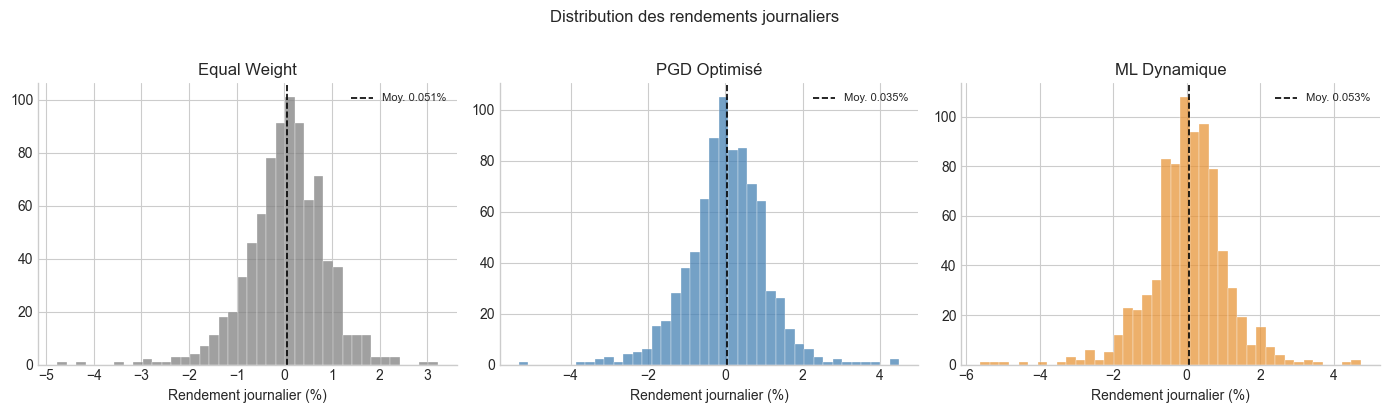

In [283]:
# Rendements journaliers — distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (key, (label, color, _)) in zip(axes, LABELS.items()):
    if key not in strategy_results:
        continue
    r = strategy_results[key]['portfolio_returns'] * 100
    ax.hist(r, bins=40, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(r.mean(), color='black', linewidth=1.2, linestyle='--',
               label=f'Moy. {r.mean():.3f}%')
    ax.set_title(label)
    ax.set_xlabel('Rendement journalier (%)')
    ax.legend(fontsize=8)

plt.suptitle('Distribution des rendements journaliers', y=1.02)
plt.tight_layout()
plt.show()

In [284]:
comparison = backtest_results['comparison'].copy()

comparison.columns = [
    'Rendement cumulé',
    'Rendement annualisé',
    'Volatilité',
    'Volatilité théorique',
    'Ratio de Sharpe',
    'Max Drawdown'
]

fmt = {
    'Rendement cumulé'    : '{:.2%}',
    'Rendement annualisé' : '{:.2%}',
    'Volatilité'          : '{:.2%}',
    'Volatilité théorique': lambda x: f'{x:.2%}' if pd.notna(x) else '—',
    'Ratio de Sharpe'     : '{:.2f}',
    'Max Drawdown'        : '{:.2%}',
}

styled = (
    comparison.style
    .format(fmt)
    .background_gradient(cmap='RdYlGn', subset=['Rendement cumulé', 'Rendement annualisé', 'Ratio de Sharpe'])
    .background_gradient(cmap='RdYlGn_r', subset=['Volatilité', 'Volatilité théorique', 'Max Drawdown'])
    .set_caption('Résumé des performances — période de test')
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '11px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
        {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '14px'), ('font-weight', 'bold')]}
    ])
)

styled

,Rendement cumulé,Rendement annualisé,Volatilité,Volatilité théorique,Ratio de Sharpe,Max Drawdown
equal_weight,47.01%,12.51%,13.23%,13.23%,0.74,-14.17%
optimized,28.53%,7.98%,15.99%,15.99%,0.37,-18.47%
dynamic,46.91%,12.48%,17.08%,—,0.60,-17.47%


## 7. Analyse de sensibilité — lambda_risk

In [285]:
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]
sens_rows = []

for lam in lambdas:
    res = run_sgd(
        returns_matrix=returns_train_with_rf,   # 🔥 CORRECTION ICI
        initial_weights=w0,
        n_iterations=5000,
        learning_rate=0.001,
        batch_size=512,
        constraint_function=enforce_portfolio_constraints,
        lambda_risk=lam,
        annualization_factor=ANNUALIZATION,
        verbose=False,
    )

    wr, wrf = split_weights(res["final_weights"])

    bt = run_static_backtest(
        returns_matrix=returns_test_with_rf,   
        weights=res["final_weights"],          
        w_rf=0.0,                           
        risk_free_rate=RISK_FREE_RATE,
        annualization_factor=ANNUALIZATION,
    )

    sens_rows.append({
        "lambda_risk": lam,
        "w_rf (%)": wrf * 100,
        "Rendement cumulé": bt["cumulative_return"],
        "Volatilité": bt["volatility"],
        "Sharpe": bt["sharpe_ratio"],
        "Max Drawdown": bt["max_drawdown"],
    })

sens_df = pd.DataFrame(sens_rows).set_index("lambda_risk")
sens_df.round(4)

,w_rf (%),Rendement cumulé,Volatilité,Sharpe,Max Drawdown
lambda_risk,,,,,
0.5,2.1876,0.3578,0.1540,0.4870,-0.1677
1.0,3.4696,0.2856,0.1613,0.3651,-0.1859
2.0,10.5805,0.2390,0.1697,0.2850,-0.2015
5.0,50.5885,0.2358,0.1021,0.3788,-0.1146
10.0,76.1928,0.1786,0.0490,0.4252,-0.0542


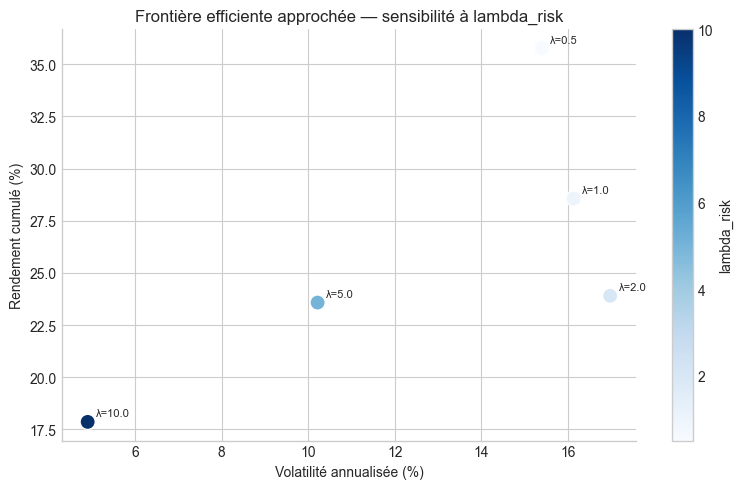

In [286]:
# Frontière efficiente approchée (rendement vs volatilité)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    sens_df['Volatilité'] * 100,
    sens_df['Rendement cumulé'] * 100,
    c=sens_df.index, cmap='Blues', s=120, zorder=5, edgecolors='white'
)
for lam, row in sens_df.iterrows():
    ax.annotate(f'λ={lam}',
                xy=(row['Volatilité']*100, row['Rendement cumulé']*100),
                xytext=(6, 4), textcoords='offset points', fontsize=8)
plt.colorbar(sc, ax=ax, label='lambda_risk')
ax.set_xlabel('Volatilité annualisée (%)')
ax.set_ylabel('Rendement cumulé (%)')
ax.set_title('Frontière efficiente approchée — sensibilité à lambda_risk')
plt.tight_layout()
plt.show()